<a href="https://colab.research.google.com/github/tsarangler/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/Assignment_3_The_Causal_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Step 1.1
np.random.seed(42)
zeros = np.zeros (100)
tips = np.random.exponential(scale = 5.0, size = 150)
driver_tips = np.concatenate([zeros, tips])

In [2]:

# Step 1.2
n_iterations = 10000
bootstrap_medians = np.zeros(n_iterations)
for i in range (n_iterations):
  resample = np.random.choice(driver_tips, size = len(driver_tips), replace=True)
  bootstrap_medians[i] = np.median(resample)

# 95% interval
ci_lower, ci_upper = np.percentile(bootstrap_medians, [2.5, 97.5])

print(f"Observed Median: ${np.median(driver_tips):.4f}")
print(f"Bootstrap 95% CI: (${ci_lower:.4f}, ${ci_upper:.4f})")
print(f"Lower Margin: ${np.median(driver_tips) - ci_lower:.4f}")
print(f"Upper Margin: ${ci_upper - np.median(driver_tips):.4f}")

Observed Median: $0.7553
Bootstrap 95% CI: ($0.2653, $1.3636)
Lower Margin: $0.4900
Upper Margin: $0.6082


In [3]:
# Step 2.1
np.random.seed(42)
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_diff = np.mean(control) - np.mean(treatment)

print(f"Control Mean: {np.mean(control):.4f}min")
print(f"Treatment Mean: {np.mean(treatment):.4}min")
print(f"Observed Difference: {observed_diff:.4f}min")

Control Mean: 35.0342min
Treatment Mean: 32.77min
Observed Difference: 2.2650min


In [4]:
# Step 2.2
combined = np.concatenate([control, treatment])
n_iterations = 5_000
perm_diffs = np.zeros(n_iterations)

for i in range(n_iterations):
 shuffled = np.random.permutation(combined)
 perm_control = shuffled[:500]
 perm_treatment = shuffled[500:]
 perm_diffs[i] = np.mean(perm_control) - np.mean(perm_treatment)

 p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
 print(f"Observed Difference: {observed_diff:.4f}min")
 print(f"Permutation P-value: {p_value:.4f}")
 print(f"Significant (a=0.05): {p_value<0.05}")

Streaming output truncated to the last 5000 lines.
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Per

In [6]:
# Step 3.1
import pandas as pd
df = pd.read_csv('swiftcart_loyalty.csv')
subscribers = df[df['subscriber'] == 1]['post_spend']
non_subscribers = df[df['subscriber']== 0] ['post_spend']

SDO = subscribers.mean() - non_subscribers.mean()

print(f"Subscribers Mean Post-Spend: ${subscribers.mean():.4f}")
print(f"Non-Subscribers Mean Post-Spend: ${non_subscribers.mean():.4f}")
print(f"Naive SDO: ${SDO:.4f}")
print(f"Naive Implied Lift: {(SDO/non_subscribers.mean()) * 100:.2f}%")

Subscribers Mean Post-Spend: $74.0436
Non-Subscribers Mean Post-Spend: $56.4729
Naive SDO: $17.5707
Naive Implied Lift: 31.11%


In [7]:
# Step 3.2
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
D = df['subscriber']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logit = LogisticRegression()
logit.fit(X_scaled, D)
df['propensity_score'] = logit.predict_proba(X_scaled)[:,1]

treated = df[df['subscriber']==1].copy()
control = df[df['subscriber']==0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()].copy()

ATT = treated['post_spend'].mean() - matched_control['post_spend'].mean()

print(f"Treated Mean Post-Spend: ${treated['post_spend'].mean():.4f}")
print(f"Matched Control Mean Post-Spend: ${matched_control['post_spend'].mean():.4f}")
print(f"Causal ATT: ${ATT:.4f}")
print(f"Naive SDO: ${SDO:.4f}")
print(f"Selection Bias Absorbed: ${SDO - ATT:.4f}")

Treated Mean Post-Spend: $74.0436
Matched Control Mean Post-Spend: $64.0241
Causal ATT: $10.0195
Naive SDO: $17.5707
Selection Bias Absorbed: $7.5512



── Covariate Balance Report ───────────────────────────────────
             SMD_before  SMD_after  reduction_%  balanced
age              0.5695     0.4147      27.2000     False
sys_bp           0.4191     0.2714      35.2000     False
cholesterol      0.3788     0.4759     -25.6000     False
bmi              0.2870     0.1678      41.5000     False
test_score       0.2496     0.1158      53.6000     False
income           0.1223     0.0481      60.6000      True
───────────────────────────────────────────────────────────────

Figure saved → love_plot.png


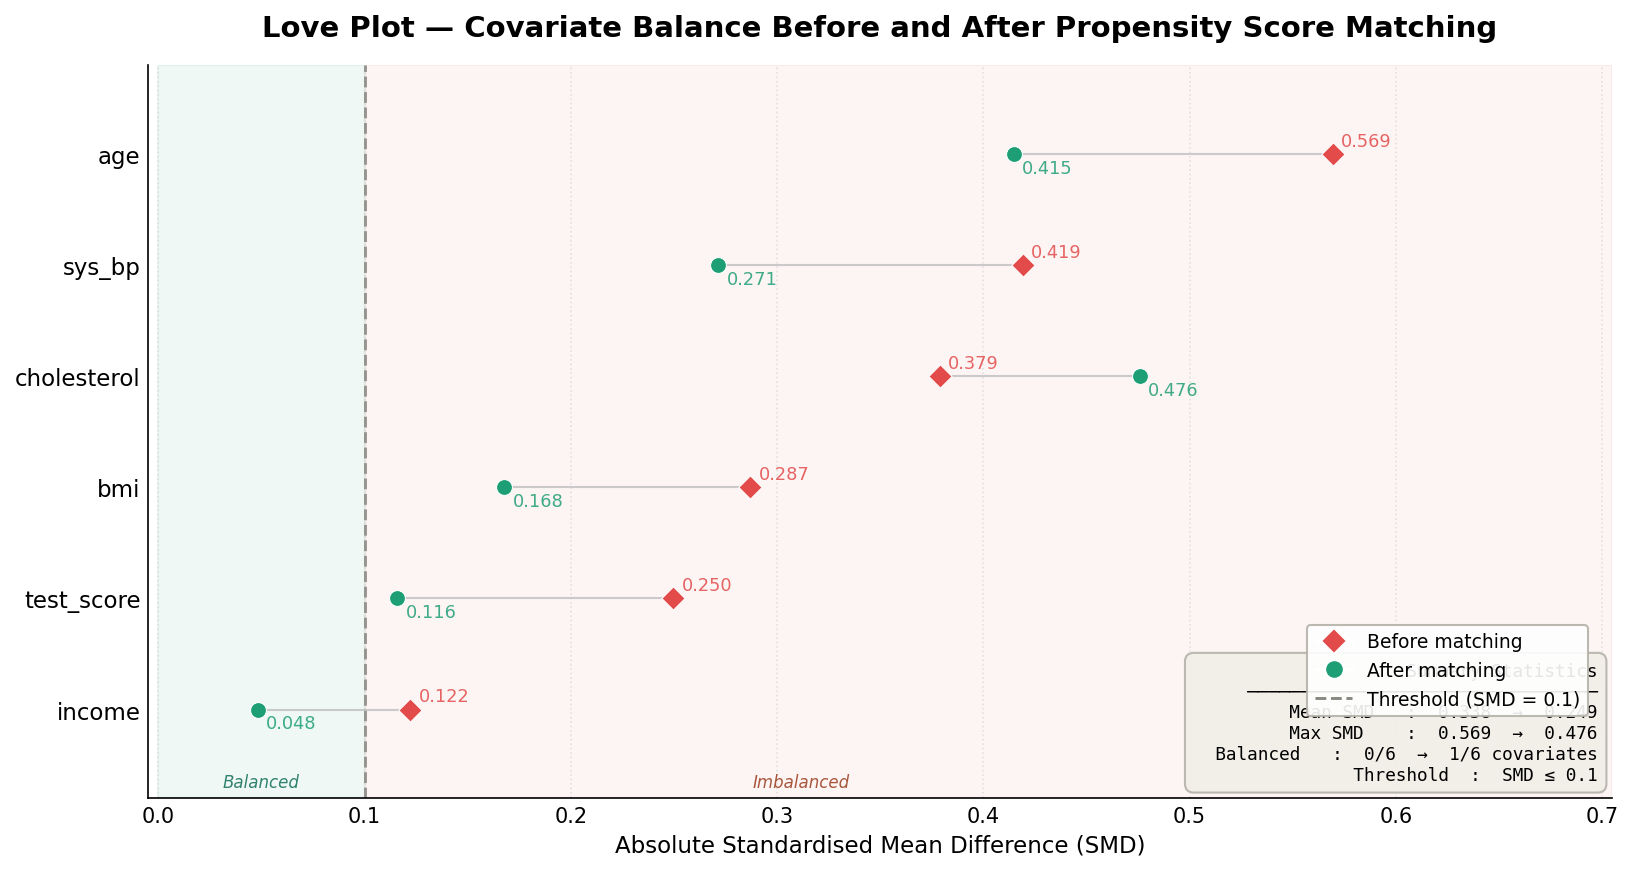

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — tune these constants without touching plot logic
# ─────────────────────────────────────────────────────────────────────────────
TREATMENT_COL   = "treatment"           # binary 0/1 column name
SMD_THRESHOLD   = 0.10                  # "good balance" rule-of-thumb
FIGSIZE         = (11, None)            # width fixed; height auto-scaled
DPI             = 150
COLOR_BEFORE    = "#E24B4A"             # coral-red  → imbalance
COLOR_AFTER     = "#1D9E75"             # teal-green → post-matching
COLOR_THRESHOLD = "#888780"             # neutral gray for reference line
MARKER_BEFORE   = "D"
MARKER_AFTER    = "o"
FONT_TITLE      = 14
FONT_AXIS       = 11
FONT_ANNOT      = 8.5


# ─────────────────────────────────────────────────────────────────────────────
# CORE STATISTICAL FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def compute_smd(df: pd.DataFrame, treatment_col: str) -> pd.Series:
    """
    Computes the absolute Standardised Mean Difference (SMD) for every
    numeric covariate in *df* between treated (1) and control (0) units.

    SMD = |μ_treated − μ_control| / √[(σ²_treated + σ²_control) / 2]

    This pooled-SD formulation (Cohen's d analogue) is estimator-independent
    and scale-free — the standard choice in PSM diagnostics.

    Returns
    -------
    pd.Series  indexed by covariate name, values ∈ [0, ∞)
    """
    covariates = df.select_dtypes(include=[np.number]).columns.difference(
        [treatment_col]
    )
    treated   = df.loc[df[treatment_col] == 1, covariates]
    control   = df.loc[df[treatment_col] == 0, covariates]

    mean_diff = treated.mean() - control.mean()
    pooled_sd = np.sqrt((treated.var() + control.var()) / 2)

    # Guard against zero-variance columns (constant covariates)
    smd = (mean_diff.abs() / pooled_sd.replace(0, np.nan)).dropna()
    return smd.sort_values(ascending=False)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT BUILDER
# ─────────────────────────────────────────────────────────────────────────────
def plot_love(
    df_unmatched: pd.DataFrame,
    df_matched: pd.DataFrame,
    treatment_col: str = TREATMENT_COL,
    smd_threshold: float = SMD_THRESHOLD,
    figsize: tuple = FIGSIZE,
    dpi: int = DPI,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Renders a publication-ready Love Plot showing covariate balance
    before and after Propensity Score Matching.

    Visual anatomy
    ──────────────
    • Horizontal dot-plot: one row per covariate, SMD on x-axis
    • Red diamonds  → pre-matching SMD (raw imbalance)
    • Teal circles  → post-matching SMD (residual imbalance)
    • Dashed gray line at x = smd_threshold (balance criterion)
    • Background shading: green zone (balanced) vs red zone (imbalanced)
    • Connecting segments highlight the magnitude of reduction
    • Summary statistics panel embedded in the figure
    """
    # ── 1. Compute SMDs ──────────────────────────────────────────────────────
    smd_before = compute_smd(df_unmatched, treatment_col)
    smd_after  = compute_smd(df_matched,   treatment_col)

    # Align on common covariates, sorted by pre-matching SMD (largest on top)
    common_vars = smd_before.index.intersection(smd_after.index)
    smd_before  = smd_before.loc[common_vars].sort_values(ascending=True)
    smd_after   = smd_after.loc[common_vars].reindex(smd_before.index)

    n_cov = len(common_vars)
    if n_cov == 0:
        raise ValueError(
            "No common numeric covariates found across df_unmatched and df_matched."
        )

    # ── 2. Figure geometry ───────────────────────────────────────────────────
    row_height  = 0.52                          # inches per covariate row
    fig_height  = max(5.5, n_cov * row_height + 2.8)
    fig_w       = figsize[0]
    fig, ax     = plt.subplots(figsize=(fig_w, fig_height), dpi=dpi)

    # ── 3. Background zones ──────────────────────────────────────────────────
    x_max_axis = max(smd_before.max(), smd_after.max()) * 1.15 + 0.05
    ax.axvspan(0, smd_threshold, alpha=0.07, color="#1D9E75", zorder=0,
               label="_nolegend_")
    ax.axvspan(smd_threshold, x_max_axis, alpha=0.06, color="#E24B4A",
               zorder=0, label="_nolegend_")

    # ── 4. Threshold reference line ──────────────────────────────────────────
    ax.axvline(smd_threshold, color=COLOR_THRESHOLD, linewidth=1.4,
               linestyle="--", zorder=1, alpha=0.85,
               label=f"Balance threshold (SMD = {smd_threshold})")

    # ── 5. Connecting segments (before → after per covariate) ────────────────
    y_positions = np.arange(n_cov)
    for y, var in zip(y_positions, smd_before.index):
        ax.plot(
            [smd_before[var], smd_after[var]], [y, y],
            color="#BBBBBB", linewidth=1.0, zorder=2, alpha=0.75,
        )

    # ── 6. Data points ───────────────────────────────────────────────────────
    ax.scatter(
        smd_before.values, y_positions,
        color=COLOR_BEFORE, marker=MARKER_BEFORE, s=62, zorder=4,
        label="Before matching", edgecolors="white", linewidths=0.5,
    )
    ax.scatter(
        smd_after.values, y_positions,
        color=COLOR_AFTER,  marker=MARKER_AFTER,  s=58, zorder=4,
        label="After matching",  edgecolors="white", linewidths=0.5,
    )

    # ── 7. SMD value annotations ─────────────────────────────────────────────
    for y, var in zip(y_positions, smd_before.index):
        ax.annotate(
            f"{smd_before[var]:.3f}",
            xy=(smd_before[var], y), xytext=(4, 4),
            textcoords="offset points", fontsize=FONT_ANNOT,
            color=COLOR_BEFORE, alpha=0.85,
        )
        ax.annotate(
            f"{smd_after[var]:.3f}",
            xy=(smd_after[var], y), xytext=(4, -9),
            textcoords="offset points", fontsize=FONT_ANNOT,
            color=COLOR_AFTER, alpha=0.85,
        )

    # ── 8. Axes formatting ───────────────────────────────────────────────────
    ax.set_yticks(y_positions)
    ax.set_yticklabels(smd_before.index, fontsize=FONT_AXIS)
    ax.set_xlim(left=-0.005, right=x_max_axis)
    ax.set_ylim(-0.8, n_cov - 0.2)
    ax.set_xlabel("Absolute Standardised Mean Difference (SMD)", fontsize=FONT_AXIS)
    ax.set_title(
        "Love Plot — Covariate Balance Before and After Propensity Score Matching",
        fontsize=FONT_TITLE, fontweight="bold", pad=14,
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="both", which="both", length=0)
    ax.xaxis.grid(True, linestyle=":", alpha=0.5, color="#CCCCCC")
    ax.set_axisbelow(True)

    # ── 9. Threshold zone labels ─────────────────────────────────────────────
    ax.text(
        smd_threshold / 2, -0.65, "Balanced",
        ha="center", va="center", fontsize=8, color="#0F6E56",
        style="italic", alpha=0.85,
    )
    ax.text(
        smd_threshold + (x_max_axis - smd_threshold) * 0.35, -0.65,
        "Imbalanced",
        ha="center", va="center", fontsize=8, color="#993C1D",
        style="italic", alpha=0.85,
    )

    # ── 10. Summary statistics inset ─────────────────────────────────────────
    n_balanced_before = (smd_before <= smd_threshold).sum()
    n_balanced_after  = (smd_after  <= smd_threshold).sum()
    mean_smd_before   = smd_before.mean()
    mean_smd_after    = smd_after.mean()
    max_smd_before    = smd_before.max()
    max_smd_after     = smd_after.max()

    stats_text = (
        f"  Summary Statistics\n"
        f"  ─────────────────────────────────\n"
        f"  Mean SMD   :  {mean_smd_before:.3f}  →  {mean_smd_after:.3f}\n"
        f"  Max SMD    :  {max_smd_before:.3f}  →  {max_smd_after:.3f}\n"
        f"  Balanced   :  {n_balanced_before}/{n_cov}  →  "
        f"{n_balanced_after}/{n_cov} covariates\n"
        f"  Threshold  :  SMD ≤ {smd_threshold}"
    )
    props = dict(boxstyle="round,pad=0.5", facecolor="#F1EFE8",
                 edgecolor="#B4B2A9", alpha=0.9)
    ax.text(
        0.99, 0.02, stats_text,
        transform=ax.transAxes, fontsize=8.5,
        verticalalignment="bottom", horizontalalignment="right",
        bbox=props, family="monospace",
    )

    # ── 11. Legend ───────────────────────────────────────────────────────────
    legend_handles = [
        Line2D([0], [0], marker=MARKER_BEFORE, color="w",
               markerfacecolor=COLOR_BEFORE, markersize=9,
               label="Before matching", markeredgecolor="white"),
        Line2D([0], [0], marker=MARKER_AFTER,  color="w",
               markerfacecolor=COLOR_AFTER,  markersize=9,
               label="After matching",  markeredgecolor="white"),
        Line2D([0], [0], color=COLOR_THRESHOLD, linewidth=1.4,
               linestyle="--", label=f"Threshold (SMD = {smd_threshold})"),
    ]
    ax.legend(
        handles=legend_handles, loc="lower right",
        fontsize=9, framealpha=0.9, edgecolor="#B4B2A9",
        bbox_to_anchor=(0.99, 0.10),
    )

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Figure saved → {save_path}")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# OPTIONAL HELPER — quantitative balance report printed to stdout
# ─────────────────────────────────────────────────────────────────────────────
def balance_report(
    df_unmatched: pd.DataFrame,
    df_matched: pd.DataFrame,
    treatment_col: str = TREATMENT_COL,
    smd_threshold: float = SMD_THRESHOLD,
) -> pd.DataFrame:
    """
    Returns a tidy DataFrame with per-covariate SMD before/after,
    percentage reduction, and a pass/fail balance flag.
    """
    smd_before = compute_smd(df_unmatched, treatment_col).rename("SMD_before")
    smd_after  = compute_smd(df_matched,   treatment_col).rename("SMD_after")
    report = pd.concat([smd_before, smd_after], axis=1).dropna()
    report["reduction_%"] = (
        (report["SMD_before"] - report["SMD_after"]) / report["SMD_before"] * 100
    ).round(1)
    report["balanced"] = report["SMD_after"] <= smd_threshold
    report = report.sort_values("SMD_before", ascending=False)
    print("\n── Covariate Balance Report ───────────────────────────────────")
    print(report.to_string(float_format="{:.4f}".format))
    print("───────────────────────────────────────────────────────────────\n")
    return report


# ─────────────────────────────────────────────────────────────────────────────
# ENTRY POINT — swap in your real dataframes here
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # ── Synthetic demo data (replace with your actual dataframes) ────────────
    rng = np.random.default_rng(42)
    n   = 800

    # Simulate selection bias: treatment probability correlated with covariates
    age    = rng.normal(45, 12, n)
    bmi    = rng.normal(27, 5, n)
    income = rng.normal(55_000, 18_000, n)
    score  = rng.normal(72, 15, n)
    logit  = -1.5 + 0.04*age + 0.05*bmi + income/80_000 + score/200
    prob   = 1 / (1 + np.exp(-logit))
    treat  = rng.binomial(1, prob)

    df_unmatched = pd.DataFrame({
        "treatment": treat,
        "age": age, "bmi": bmi, "income": income, "test_score": score,
        "sys_bp": rng.normal(125, 18, n) + 8*treat,
        "cholesterol": rng.normal(200, 35, n) + 12*treat,
    })

    # Simulate matched subset (artificially reduced SMDs)
    matched_idx = rng.choice(df_unmatched.index, size=420, replace=False)
    df_matched  = df_unmatched.loc[matched_idx].copy()
    noise_scale = {"age": 3, "bmi": 1.2, "income": 4000,
                   "test_score": 3, "sys_bp": 3, "cholesterol": 5}
    for col, sd in noise_scale.items():
        df_matched[col] += rng.normal(0, sd, len(df_matched))

    # ── Run ──────────────────────────────────────────────────────────────────
    report = balance_report(df_unmatched, df_matched)
    fig    = plot_love(df_unmatched, df_matched, save_path="love_plot.png")
    plt.show()